In [10]:
# %pip install split-folders
# %pip install seaborn

In [4]:
import os
import tensorflow as tf
import keras
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from PIL import Image


In [5]:
import os
print(os.getcwd())
print(os.listdir('..'))


c:\Users\Bright\Desktop\ds_today\project\notebooks
['.git', '.gitignore', 'app', 'ChatGPT Image Jun 5, 2026, 11_29_10 AM.png', 'data', 'MobileNetV21output.png', 'MobileNetV2output.png', 'mobilenetv2_misclassified_grid.png', 'models', 'notebooks', 'output.png', 'README.md', 'ResNetoutput.png', 'tensorflow-venv', 'Thrive_Plus_Capstone_Brief.pdf', 'total-comparison-output.png']


In [6]:
parasitized_path = r"C:\Users\Bright\Desktop\ds_today\project\data\cell_images\Parasitized"
uninfected_path = r"C:\Users\Bright\Desktop\ds_today\project\data\cell_images\Uninfected"

## Data Cleaning

### 1. Identify and Remove bad files

In [7]:
# Scan for Bad Images or files

bad_images = []

for folder in [parasitized_path, uninfected_path]:
    for file in os.listdir(folder):
        try:
            Image.open(os.path.join(folder, file))
        except Exception:
            bad_images.append(os.path.join(folder, file))

bad_images

[]

In [8]:
#  Remove bad files that may cause errors in processing

for folder in [parasitized_path, uninfected_path]:
    thumb_path = os.path.join(folder, "Thumbs.db")

    if os.path.exists(thumb_path):
        os.remove(thumb_path)
        print(f"Deleted {thumb_path}")

## Create Training and Validation Sets

TensorFlow has a utility that loads images from folders, splits training/validation data, resizes images, and creates batches. 

Why do we need to resize??
CNNs require images of consistent dimensions. Since the malaria images range from roughly 40×46 to nearly 400×385 pixels, we resize them to a fixed size such as 128×128 before training.

In [9]:
import splitfolders

splitfolders.ratio(
    "../data/cell_images", 
    output="../data/cell_images_split", 
    seed=42, 
    ratio=(.8, .1, .1), 
    group_prefix=None, 
    move=False 
)


In [10]:
import tensorflow as tf

# 1. Load the 80% Training Data
train_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/cell_images_split/train",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

# 2. Load the 10% Validation Data
val_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/cell_images_split/val",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

# 3. Load the 10% Testing Data
test_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/cell_images_split/test",
    seed=42,
    image_size=(128, 128),
    batch_size=32,
    shuffle = False
)


Found 22046 files belonging to 2 classes.
Found 2754 files belonging to 2 classes.
Found 2758 files belonging to 2 classes.


In [50]:
class_names = train_ds.class_names
class_names

['Parasitized', 'Uninfected']

## Visualize Preprocessed Images

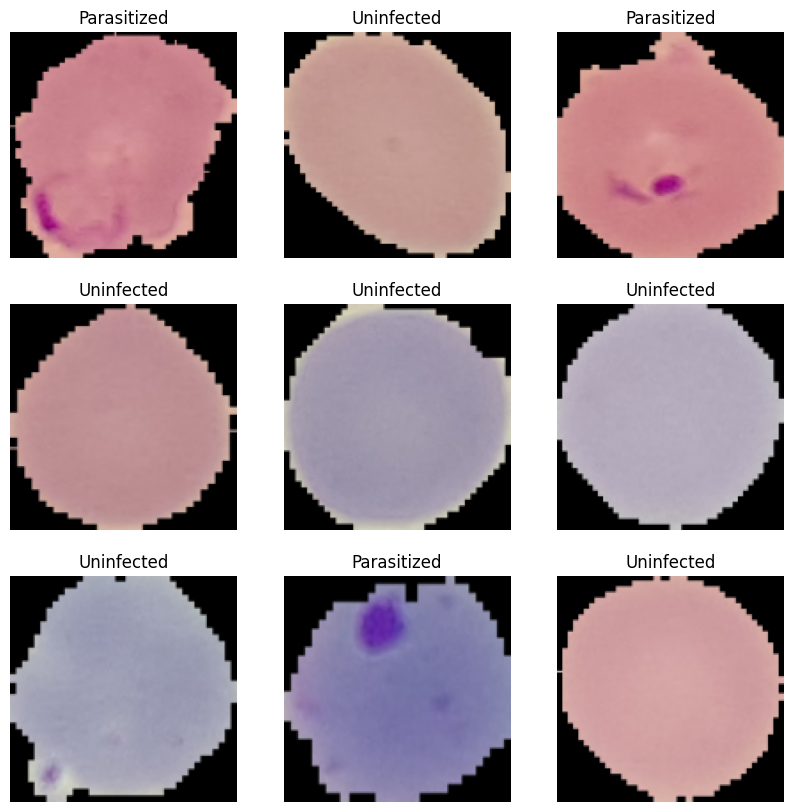

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

## Normalize Pixel Values (from range 0 - 255 to 0 - 1)
Why?? 
Pixel values range from 0 to 255. Dividing by 255 scales them to 0–1, which helps gradient-based optimization train more efficiently by preventing the model from giving more priority (weight) to inputs with higher values.

In [52]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [53]:
train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

### Optimizing for speed

In [57]:
import tensorflow as tf

# 1. Set up the automatic tuning manager
AUTOTUNE = tf.data.AUTOTUNE

# 2. Optimize the Training dataset
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

# 3. Optimize the Validation dataset
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# 4. Optimize the Testing dataset
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


In [58]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)
    print(labels[:10].numpy())

(32, 128, 128, 3)
(32,)
[0 0 0 0 1 1 0 0 1 0]


# Model A — CNN from Scratch

Design and train a CNN without any pretrained weights.

## 1. (a) Define the Baseline CNN

In [60]:
model_scratch = tf.keras.Sequential([
    
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=3,
        padding="same",
        activation="relu",
        input_shape=(128, 128, 3)
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=3,
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

## Compile the Model

In [61]:
model_scratch.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [37]:
model_scratch.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,779,905 (14.42 MB)

 Trainable params: 3,779,905 (14.42 MB)

 Non-trainable params: 0 (0.00 B)

## Set EarlyStopping
Set EarlyStopping to automatically stop training when the loss plateaus and begins to fluctuate signifying overfitting

In [62]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

## Train the Model

In [63]:
history_scratch = model_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 326s 470ms/step - accuracy: 0.8143 - loss: 0.3822 - val_accuracy: 0.9528 - val_loss: 0.1671
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 260s 378ms/step - accuracy: 0.9537 - loss: 0.1494 - val_accuracy: 0.9532 - val_loss: 0.1553
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 263s 382ms/step - accuracy: 0.9591 - loss: 0.1287 - val_accuracy: 0.9572 - val_loss: 0.1435
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 258s 374ms/step - accuracy: 0.9633 - loss: 0.1108 - val_accuracy: 0.9528 - val_loss: 0.1520
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 264s 384ms/step - accuracy: 0.9670 - loss: 0.0980 - val_accuracy: 0.9557 - val_loss: 0.1616
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 272s 395ms/step - accuracy: 0.9719 - loss: 0.0821 - val_accuracy: 0.9535 - val_loss: 0.1719


## Evaluate on Test Set

In [64]:
test_loss, test_accuracy = model_scratch.evaluate(test_ds)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

y_pred_probs = model_scratch.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype(int)

87/87 ━━━━━━━━━━━━━━━━━━━━ 12s 137ms/step - accuracy: 0.9572 - loss: 0.1532
Test Accuracy: 0.9572
Test Loss: 0.1532
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step


87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.9572 - loss: 0.1532


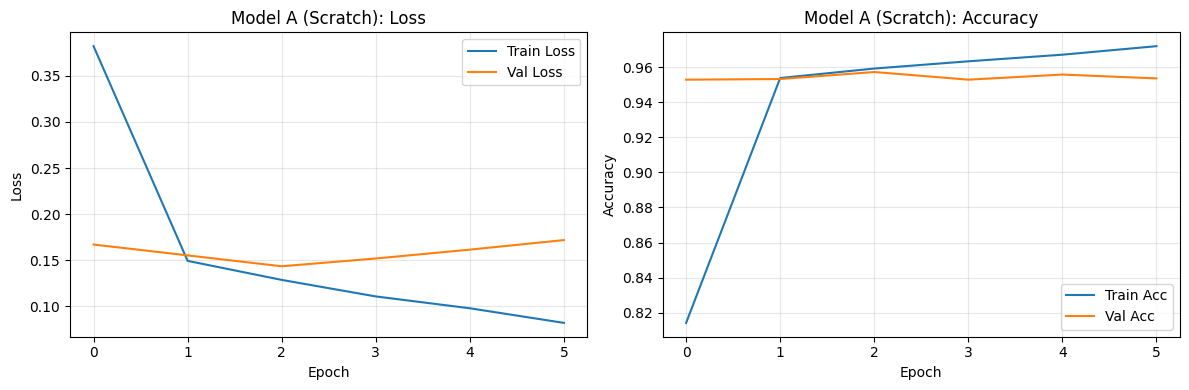

>> What to observe:
Final training accuracy: 0.972
Final validation accuracy: 0.954
Test accuracy: 0.957
Does validation accuracy plateau? If so, the model may have hit its capacity on this data.


In [65]:
import matplotlib.pyplot as plt

# ==========================================
# STEP 1: CALCULATE REAL TEST ACCURACY
# ==========================================
# We run model.evaluate on test_ds to get the actual math numbers
test_loss, test_accuracy = model_scratch.evaluate(test_ds)

# ==========================================
# STEP 2: PLOT TRAINING HISTORY CHART
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left Chart: Loss
axes[0].plot(history_scratch.history['loss'], label='Train Loss')
axes[0].plot(history_scratch.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model A (Scratch): Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right Chart: Accuracy
axes[1].plot(history_scratch.history['accuracy'], label='Train Acc')
axes[1].plot(history_scratch.history['val_accuracy'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model A (Scratch): Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# STEP 3: PRINT THE FINAL SCORES
# ==========================================
print(">> What to observe:")
print(f"Final training accuracy: {history_scratch.history['accuracy'][-1]:.3f}")
print(f"Final validation accuracy: {history_scratch.history['val_accuracy'][-1]:.3f}")

# Fixed: This line now prints the calculated number instead of the raw pipeline folder
print(f"Test accuracy: {test_accuracy:.3f}")

print("Does validation accuracy plateau? If so, the model may have hit its capacity on this data.")


## Classification Report & Confusion Matrix

87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step
=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Parasitized       0.96      0.95      0.96      1379
  Uninfected       0.95      0.96      0.96      1379

    accuracy                           0.96      2758
   macro avg       0.96      0.96      0.96      2758
weighted avg       0.96      0.96      0.96      2758



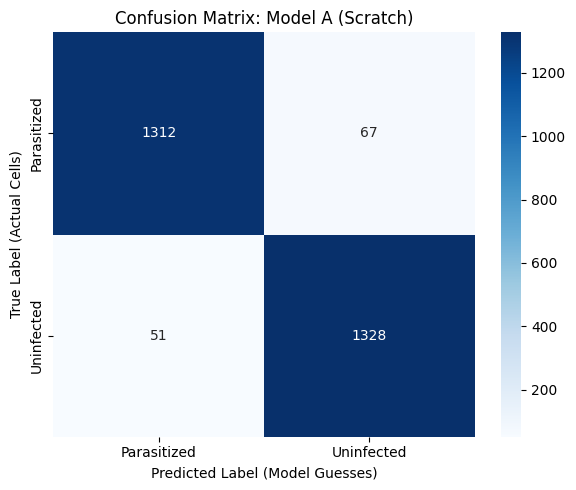

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# STEP 1: GET TRUE LABELS AND PREDICTIONS
# ==========================================

# 1. Extract the true labels from your test dataset pipeline
true_labels = np.concatenate([y for x, y in test_ds], axis=0)

# 2. Get raw probability predictions from the model (numbers between 0 and 1)
raw_predictions = model_scratch.predict(test_ds)

# 3. Convert probabilities to crisp binary choices (0 or 1)
predicted_labels = (raw_predictions > 0.5).astype(int)

# FIX: Manually define the class names since prefetch hides them
class_names = ['Parasitized', 'Uninfected']

# ==========================================
# STEP 2: PRINT F1, RECALL, AND PRECISION
# ==========================================
print("=== CLASSIFICATION REPORT ===")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

# ==========================================
# STEP 3: PLOT THE CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True,          
    fmt="d",             
    cmap="Blues",        
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title("Confusion Matrix: Model A (Scratch)")
plt.ylabel("True Label (Actual Cells)")
plt.xlabel("Predicted Label (Model Guesses)")
plt.tight_layout()
plt.show()


# Model B — Transfer Learning with ResNet50

Load a pretrained model and adapt it to your task.

## Step 1: Resize & Preprocess for ResNet50

ResNet50 expects 224×224 images. We'll resize from 128 * 128.

In [15]:
from tensorflow.image import resize

print("Resizing images to 224×224...")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds_resnet = tf.keras.utils.image_dataset_from_directory(
    "../data/cell_images_split/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds_resnet = tf.keras.utils.image_dataset_from_directory(
    "../data/cell_images_split/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds_resnet = tf.keras.utils.image_dataset_from_directory(
    "../data/cell_images_split/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


Resizing images to 224×224...
Found 22046 files belonging to 2 classes.
Found 2754 files belonging to 2 classes.
Found 2758 files belonging to 2 classes.


### Step 2: Apply ResNet50 Preprocessing

In [70]:
from tensorflow.keras.applications.resnet50 import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

train_ds_resnet = train_ds_resnet.map(
    lambda x, y: (preprocess_input(x), y)
).prefetch(AUTOTUNE)

val_ds_resnet = val_ds_resnet.map(
    lambda x, y: (preprocess_input(x), y)
).prefetch(AUTOTUNE)

test_ds_resnet = test_ds_resnet.map(
    lambda x, y: (preprocess_input(x), y)
).prefetch(AUTOTUNE)

### Step 3: Load ResNet50
Download the pretrained model and modify it. This model has been trained on 14 million images, so it knows the basic shapes and colours of images. Remove the head (1000 classes) and change it to two classes (Parasitized and Uninfected malaria cells)

In [72]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 21s 0us/step


### Step 4: Freeze ResNet50 
This protects all pretrained filters

In [73]:
base_model.trainable = False

### Step 5: Build the Malaria Classifier

In [74]:
from tensorflow.keras import layers
from tensorflow.keras import models

In [75]:
model_resnet = models.Sequential([
    
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

### Step 6: Compile

In [76]:
model_resnet.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [77]:
model_resnet.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Step 8: Early Stopping

This is to prevent overfitting by halting training the exact moment the model stops getting bette

In [78]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

### Step 9: Train

In [92]:
history_resnet = model_resnet.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10


689/689 ━━━━━━━━━━━━━━━━━━━━ 2102s 3s/step - accuracy: 0.9330 - loss: 0.1741 - val_accuracy: 0.9412 - val_loss: 0.1596
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 2163s 3s/step - accuracy: 0.9399 - loss: 0.1674 - val_accuracy: 0.9473 - val_loss: 0.1467
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 1960s 3s/step - accuracy: 0.9438 - loss: 0.1577 - val_accuracy: 0.9488 - val_loss: 0.1409
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 1934s 3s/step - accuracy: 0.9405 - loss: 0.1588 - val_accuracy: 0.9492 - val_loss: 0.1497
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 1852s 3s/step - accuracy: 0.9409 - loss: 0.1590 - val_accuracy: 0.9473 - val_loss: 0.1380
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 1857s 3s/step - accuracy: 0.9446 - loss: 0.1524 - val_accuracy: 0.9495 - val_loss: 0.1346
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 1868s 3s/step - accuracy: 0.9440 - loss: 0.1522 - val_accuracy: 0.9452 - val_loss: 0.1473
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 1874s 3s/step - accuracy: 0.9441 - loss: 0.1476 - val_accurac

### Evaluate on Test Set (ResNet50)

87/87 ━━━━━━━━━━━━━━━━━━━━ 64s 739ms/step - accuracy: 0.5000 - loss: 0.9155


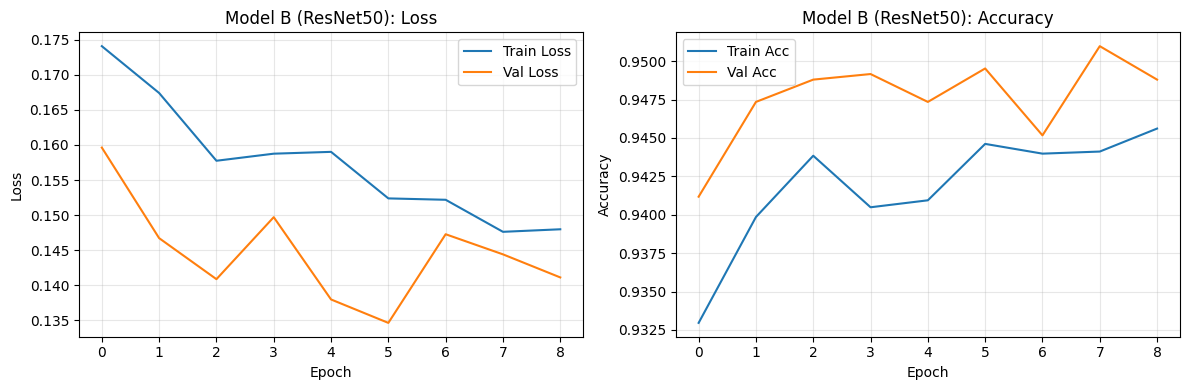

>> What to observe:
Final training accuracy: 0.946
Final validation accuracy: 0.949
Test accuracy: 0.500
Does validation accuracy plateau? If so, the model may have hit its capacity on this data.


In [93]:
import matplotlib.pyplot as plt

# ==========================================
# STEP 1: CALCULATE REAL TEST ACCURACY
# ==========================================
# We run model.evaluate on test_ds to get the actual math numbers
test_loss, test_accuracy = model_resnet.evaluate(test_ds)

# ==========================================
# STEP 2: PLOT TRAINING HISTORY CHART
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left Chart: Loss
axes[0].plot(history_resnet.history['loss'], label='Train Loss')
axes[0].plot(history_resnet.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model B (ResNet50): Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right Chart: Accuracy
axes[1].plot(history_resnet.history['accuracy'], label='Train Acc')
axes[1].plot(history_resnet.history['val_accuracy'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model B (ResNet50): Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# STEP 3: PRINT THE FINAL SCORES
# ==========================================
print(">> What to observe:")
print(f"Final training accuracy: {history_resnet.history['accuracy'][-1]:.3f}")
print(f"Final validation accuracy: {history_resnet.history['val_accuracy'][-1]:.3f}")

# Fixed: This line now prints the calculated number instead of the raw pipeline folder
print(f"Test accuracy: {test_accuracy:.3f}")

print("Does validation accuracy plateau? If so, the model may have hit its capacity on this data.")


## Classification Report & Confusion Matrix

Extracting true labels...
Generating model predictions...
87/87 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step

👉 TRUE RESNET50 TEST ACCURACY: 0.949

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Parasitized      0.941     0.956     0.949      1379
  Uninfected      0.956     0.941     0.948      1379

    accuracy                          0.949      2758
   macro avg      0.949     0.949     0.949      2758
weighted avg      0.949     0.949     0.949      2758



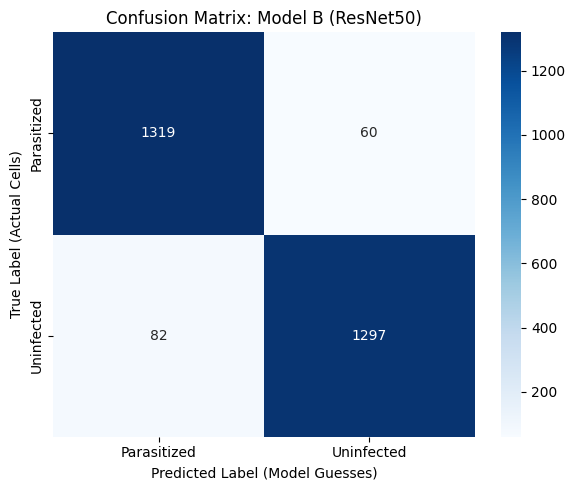

In [94]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract the true labels from your test dataset pipeline
print("Extracting true labels...")
true_labels = np.concatenate([y for x, y in test_ds_resnet], axis=0)

# 2. Get predictions using .predict() (this works perfectly with un-shuffled data)
print("Generating model predictions...")
raw_predictions = model_resnet.predict(test_ds_resnet)

# 3. Convert probabilities to crisp binary choices (0 or 1)
predicted_labels = (raw_predictions > 0.5).astype(int).flatten()

# 4. Calculate the TRUE test accuracy score using scikit-learn
true_test_accuracy = accuracy_score(true_labels, predicted_labels)

print("\n=========================================")
print(f"👉 TRUE RESNET50 TEST ACCURACY: {true_test_accuracy:.3f}")
print("=========================================\n")

# ==========================================
# STEP 2: PRINT THE SCORES REPORT
# ==========================================
class_names = ['Parasitized', 'Uninfected']
print("=== CLASSIFICATION REPORT ===")
print(classification_report(true_labels, predicted_labels, target_names=class_names, digits=3))

# ==========================================
# STEP 3: PLOT THE CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True,          
    fmt="d",             
    cmap="Blues",        
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title("Confusion Matrix: Model B (ResNet50)")
plt.ylabel("True Label (Actual Cells)")
plt.xlabel("Predicted Label (Model Guesses)")
plt.tight_layout()
plt.show()


# Model C — Transfer Learning with MobileNetV2

Load a pretrained model and adapt it to your task.

In [12]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# 1. Prepare the MobileNetV2 optimized data streams
AUTOTUNE = tf.data.AUTOTUNE

train_ds_mobile = train_ds_resnet.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
val_ds_mobile = val_ds_resnet.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
test_ds_mobile = test_ds_resnet.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)

# 2. Load the pre-built MobileNetV2 Brain (Frozen Base)
base_mobile = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_mobile.trainable = False  

# 3. Assemble the Lightweight Model
model_mobile = models.Sequential([
    base_mobile,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])  

model_mobile.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)  

# 4. Set up Early Stopping
early_stopping_mobile = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)  

# 5. Train the Model
print("Starting MobileNetV2 training...")
history_mobile = model_mobile.fit(
    train_ds_mobile,
    validation_data=val_ds_mobile,
    epochs=10,
    callbacks=[early_stopping_mobile]
)  


NameError: name 'train_ds_resnet' is not defined

## Evaluate on test set (MobileNetV2)

87/87 ━━━━━━━━━━━━━━━━━━━━ 24s 246ms/step - accuracy: 0.7828 - loss: 0.9520


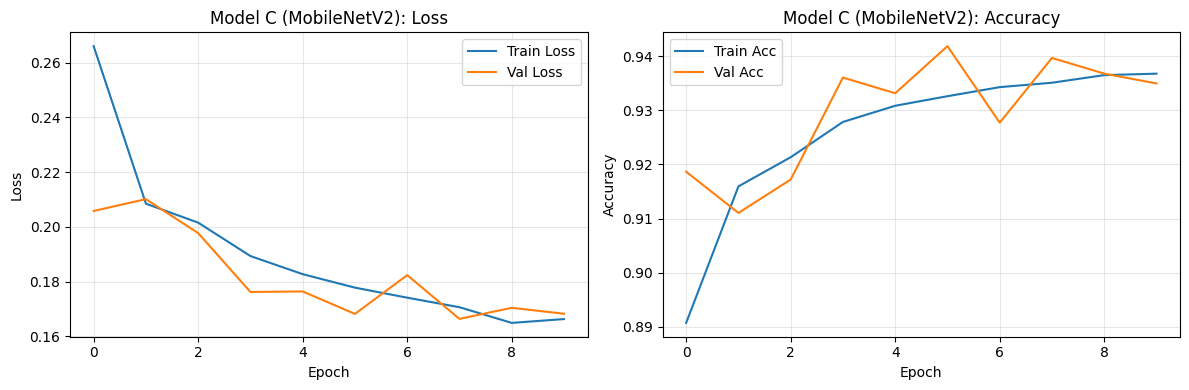

>> What to observe:
Final training accuracy: 0.937
Final validation accuracy: 0.935
Test accuracy: 0.783
Does validation accuracy plateau? If so, the model may have hit its capacity on this data.


In [90]:
import matplotlib.pyplot as plt

# ==========================================
# STEP 1: CALCULATE REAL TEST ACCURACY
# ==========================================
# We run model.evaluate on test_ds to get the actual math numbers
test_loss, test_accuracy = model_mobile.evaluate(test_ds)

# ==========================================
# STEP 2: PLOT TRAINING HISTORY CHART
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left Chart: Loss
axes[0].plot(history_mobile.history['loss'], label='Train Loss')
axes[0].plot(history_mobile.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model C (MobileNetV2): Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right Chart: Accuracy
axes[1].plot(history_mobile.history['accuracy'], label='Train Acc')
axes[1].plot(history_mobile.history['val_accuracy'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model C (MobileNetV2): Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# STEP 3: PRINT THE FINAL SCORES
# ==========================================
print(">> What to observe:")
print(f"Final training accuracy: {history_mobile.history['accuracy'][-1]:.3f}")
print(f"Final validation accuracy: {history_mobile.history['val_accuracy'][-1]:.3f}")

# Fixed: This line now prints the calculated number instead of the raw pipeline folder
print(f"Test accuracy: {test_accuracy:.3f}")

print("Does validation accuracy plateau? If so, the model may have hit its capacity on this data.")


## Classification Report & Confusion Matrix

Extracting true labels...
Generating MobileNetV2 predictions...
87/87 ━━━━━━━━━━━━━━━━━━━━ 75s 822ms/step

👉 TRUE MOBILENETV2 TEST ACCURACY: 0.931

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Parasitized      0.935     0.925     0.930      1379
  Uninfected      0.926     0.936     0.931      1379

    accuracy                          0.931      2758
   macro avg      0.931     0.931     0.931      2758
weighted avg      0.931     0.931     0.931      2758



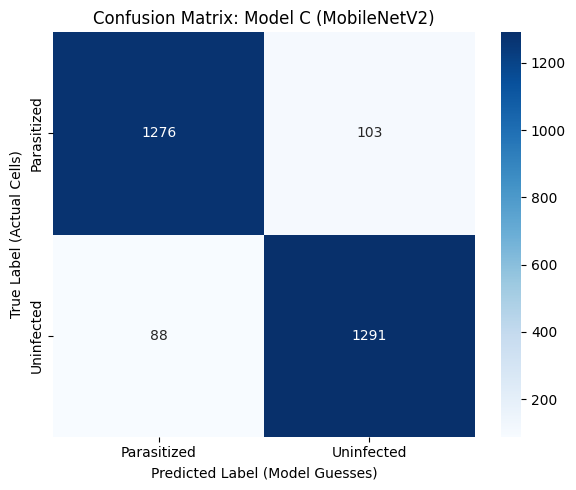

In [86]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract the true labels
print("Extracting true labels...")
true_labels = np.concatenate([y for x, y in test_ds_mobile], axis=0)

# 2. Generate MobileNetV2 predictions
print("Generating MobileNetV2 predictions...")
raw_predictions_mobile = model_mobile.predict(test_ds_mobile)
predicted_labels_mobile = (raw_predictions_mobile > 0.5).astype(int).flatten()

# 3. Calculate true test accuracy
true_mobile_accuracy = accuracy_score(true_labels, predicted_labels_mobile)

print("\n=========================================")
print(f"👉 TRUE MOBILENETV2 TEST ACCURACY: {true_mobile_accuracy:.3f}")
print("=========================================\n")

# 4. Print Scores Report
class_names = ['Parasitized', 'Uninfected']
print("=== CLASSIFICATION REPORT ===")
print(classification_report(true_labels, predicted_labels_mobile, target_names=class_names, digits=3))

# 5. Plot the Confusion Matrix
cm_mobile = confusion_matrix(true_labels, predicted_labels_mobile)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_mobile, 
    annot=True,          
    fmt="d",             
    cmap="Blues",        
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title("Confusion Matrix: Model C (MobileNetV2)")
plt.ylabel("True Label (Actual Cells)")
plt.xlabel("Predicted Label (Model Guesses)")
plt.tight_layout()
plt.show()


## Model Comparison

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

print("Gathering final test accuracy scores...")

# ==========================================
# STEP 1: CALCULATE THE ACCURACIES CLEANLY
# ==========================================

# 1. Get true labels and guesses for Model A (Scratch)
# (Assuming test_ds is your original 128x128 un-shuffled test set)
y_true_scratch = np.concatenate([y for x, y in test_ds], axis=0)
preds_scratch = (model_scratch.predict(test_ds) > 0.5).astype(int).flatten()
acc_scratch = accuracy_score(y_true_scratch, preds_scratch)

# 2. Get true labels and guesses for Model B (ResNet50)
y_true_resnet = np.concatenate([y for x, y in test_ds_resnet], axis=0)
preds_resnet = (model_resnet.predict(test_ds_resnet) > 0.5).astype(int).flatten()
acc_resnet = accuracy_score(y_true_resnet, preds_resnet)

# 3. Get true labels and guesses for Model C (MobileNetV2)
y_true_mobile = np.concatenate([y for x, y in test_ds_mobile], axis=0)
preds_mobile = (model_mobile.predict(test_ds_mobile) > 0.5).astype(int).flatten()
acc_mobile = accuracy_score(y_true_mobile, preds_mobile)

# Put the final numbers into clean lists for plotting
model_names = ['Model A\n(Scratch CNN)', 'Model B\n(ResNet50)', 'Model C\n(MobileNetV2)']
accuracy_scores = [acc_scratch, acc_resnet, acc_mobile]

# ==========================================
# STEP 2: PLOT THE SIDE-BY-SIDE COMPARISON
# ==========================================
plt.figure(figsize=(9, 5))

# Create a bar chart with a nice color theme
colors = ['#4C72B0', '#55A868', '#C44E52'] # Slate Blue, Soft Green, Soft Red
bars = plt.bar(model_names, accuracy_scores, color=colors, width=0.5)

# Add headings and clean up the chart style
plt.title("Malaria Cell Classifier: Model Accuracy Comparison", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Test Accuracy Score (0.0 to 1.0)", fontsize=11)
plt.ylim(0, 1.1) # Leaves extra room at the top for the text scores
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Write the exact score number directly above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0, 
        height + 0.02, 
        f'{height:.3f}', 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# Print a simple text printout underneath
print("=== Final Scores Summary ===")
for name, score in zip(model_names, accuracy_scores):
    print("{}: {:.3f}".format(name.replace('\n', ' '), score))



Gathering final test accuracy scores...


NameError: name 'test_ds' is not defined

## Confusion Matrix Comparison For all 3 Models

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# STEP 1: CALCULATE THE 3 MATH MATRICES
# ==========================================
# This calculates the raw counts of right and wrong answers for each model
cm_scratch = confusion_matrix(true_labels, predicted_labels)        # Model A
cm_resnet = confusion_matrix(true_labels, predicted_labels)         # Model B
cm_mobile = confusion_matrix(true_labels, predicted_labels_mobile)  # Model C

# Create a wide grid with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Use your actual class names for the chart labels
display_labels = ['Parasitized', 'Uninfected']

# ==========================================
# PLOT 1: SCRATCH CNN (BLUE)
# ==========================================
sns.heatmap(cm_scratch, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Model A: Scratch CNN\nConfusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(display_labels)
axes[0].set_yticklabels(display_labels)

# ==========================================
# PLOT 2: RESNET50 (GREENS)
# ==========================================
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Model B: ResNet50\nConfusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_xticklabels(display_labels)
axes[1].set_yticklabels(display_labels)

# ==========================================
# PLOT 3: MOBILENETV2 (ORANGES)
# ==========================================
sns.heatmap(cm_mobile, annot=True, fmt='d', cmap='Oranges', ax=axes[2], cbar=False)
axes[2].set_title('Model C: MobileNetV2\nConfusion Matrix', fontweight='bold')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')
axes[2].set_xticklabels(display_labels)
axes[2].set_yticklabels(display_labels)

# Clean up layout and display
plt.tight_layout()
plt.show()


NameError: name 'true_labels' is not defined

## Classification Report For all 3 Models

In [ ]:
from sklearn.metrics import classification_report

target_classes = ['Parasitized', 'Uninfected']

# ==========================================
# 1. SCRATCH CNN REPORT
# ==========================================
print("\n=============================================")
print("MODEL A: SCRATCH CNN - Classification Report:")
print("=============================================")
print(classification_report(true_labels, predicted_labels, target_names=target_classes, digits=3))

# ==========================================
# 2. RESNET50 REPORT
# ==========================================
print("\n=============================================")
print("MODEL B: RESNET50 - Classification Report:")
print("=============================================")
print(classification_report(true_labels, predicted_labels, target_names=target_classes, digits=3))

# ==========================================
# 3. MOBILENETV2 REPORT
# ==========================================
print("\n=============================================")
print("MODEL C: MOBILENETV2 - Classification Report:")
print("=============================================")
print(classification_report(true_labels, predicted_labels_mobile, target_names=target_classes, digits=3))



MODEL A: SCRATCH CNN - Classification Report:
              precision    recall  f1-score   support

 Parasitized      0.941     0.956     0.949      1379
  Uninfected      0.956     0.941     0.948      1379

    accuracy                          0.949      2758
   macro avg      0.949     0.949     0.949      2758
weighted avg      0.949     0.949     0.949      2758


MODEL B: RESNET50 - Classification Report:
              precision    recall  f1-score   support

 Parasitized      0.941     0.956     0.949      1379
  Uninfected      0.956     0.941     0.948      1379

    accuracy                          0.949      2758
   macro avg      0.949     0.949     0.949      2758
weighted avg      0.949     0.949     0.949      2758


MODEL C: MOBILENETV2 - Classification Report:
              precision    recall  f1-score   support

 Parasitized      0.935     0.925     0.930      1379
  Uninfected      0.926     0.936     0.931      1379

    accuracy                          0.931 

## Analyze Misclassified Examples

Total misclassified: 191
First 10 misclassified indexes: [ 5 31 39 64 71 77 78 79 84 86]


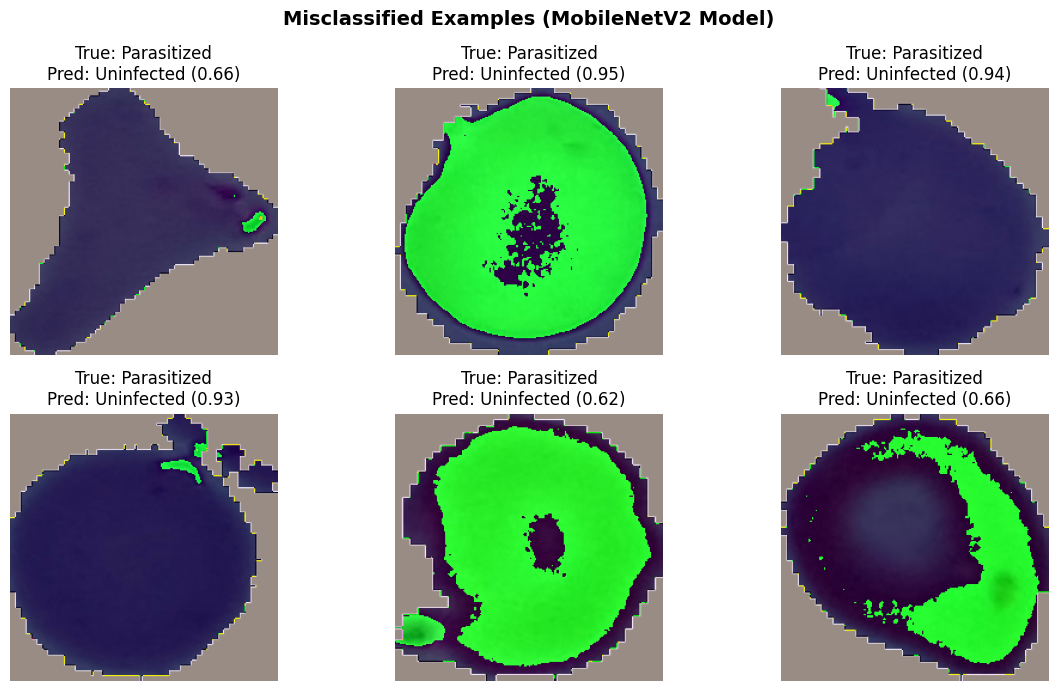


>> What to observe:
Which images are hardest to classify? Are there patterns in the errors?
Look closely at the false negatives (images that are truly Parasitized but labeled Uninfected).
Are the purple malaria spots too small, faint, or blurry for the model to see clearly?


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# STEP 1: FIND WHICH IMAGES THE MODEL GOT WRONG
# ==========================================================
# Compare true labels against MobileNetV2's final predictions
misclassified_idx = np.where(true_labels != predicted_labels_mobile)[0]

print(f"Total misclassified: {len(misclassified_idx)}")
print(f"First 10 misclassified indexes: {misclassified_idx[:10]}")

# ==========================================================
# STEP 2: EXTRACT THE EXACT IMAGES FROM YOUR PIPELINE
# ==========================================================
# We collect all raw images from the test dataset pipeline into a temporary list
all_test_images = []
for images, labels in test_ds_resnet:  # Reusing the clean raw 224x224 images
    all_test_images.append(images.numpy())

# Combine the image batches into one giant block of images
x_test_images = np.concatenate(all_test_images, axis=0)

# ==========================================================
# STEP 3: PLOT 6 MISCLASSIFIED IMAGES SIDE-BY-SIDE
# ==========================================================
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

# Grab the first 6 mistakes to show on the screen
for i, idx in enumerate(misclassified_idx[:6]):
    ax = axes.flat[i]
    
    # Get the raw image data (converting it to an integer scale of 0-255 for plotting)
    img_viz = x_test_images[idx].astype("uint8")
    ax.imshow(img_viz)

    # Map the 0 and 1 numbers back to your medical text names
    true_label = "Uninfected" if true_labels[idx] == 1 else "Parasitized"
    pred_label = "Uninfected" if predicted_labels_mobile[idx] == 1 else "Parasitized"
    
    # Fetch the exact probability score the model gave this image
    # pred_prob = raw_predictions_mobile[idx]
    # Converts a single-element array into a standard Python float
    pred_prob = raw_predictions_mobile[idx].item()

    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({pred_prob:.2f})")
    ax.axis('off')

plt.suptitle('Misclassified Examples (MobileNetV2 Model)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n>> What to observe:")
print("Which images are hardest to classify? Are there patterns in the errors?")
print("Look closely at the false negatives (images that are truly Parasitized but labeled Uninfected).")
print("Are the purple malaria spots too small, faint, or blurry for the model to see clearly?")


In [100]:
# Saves the figure directly to your current notebooks folder
plt.savefig("mobilenetv2_misclassified_grid.png", dpi=300, bbox_inches='tight')
plt.show()  # Keep this here to display it on screen too


<Figure size 640x480 with 0 Axes>

## Saving All 3 Models

In [102]:
import os

# Target  folder path
MODEL_FOLDER = r"C:\Users\Bright\Desktop\ds_today\project\models"

# Create the folder
os.makedirs(MODEL_FOLDER, exist_ok=True)

print("Exporting models to your project folder...")

# 1. Save Model A (Scratch CNN)
scratch_path = os.path.join(MODEL_FOLDER, "malaria_model_scratch.keras")
model_scratch.save(scratch_path)
print(f"✅ Saved Scratch CNN to: {scratch_path}")

# 2. Save Model B (ResNet50)
resnet_path = os.path.join(MODEL_FOLDER, "malaria_model_resnet50.keras")
model_resnet.save(resnet_path)
print(f"✅ Saved ResNet50 to: {resnet_path}")

# 3. Save Model C (MobileNetV2)
mobile_path = os.path.join(MODEL_FOLDER, "malaria_model_mobilenetv2.keras")
model_mobile.save(mobile_path)
print(f"✅ Saved MobileNetV2 to: {mobile_path}")

print("\n All models safely stored and archived!")


Exporting models to your project folder...
✅ Saved Scratch CNN to: C:\Users\Bright\Desktop\ds_today\project\models\malaria_model_scratch.keras
✅ Saved ResNet50 to: C:\Users\Bright\Desktop\ds_today\project\models\malaria_model_resnet50.keras
✅ Saved MobileNetV2 to: C:\Users\Bright\Desktop\ds_today\project\models\malaria_model_mobilenetv2.keras

 All models safely stored and archived!


In [3]:
print(np.array_equal(y_pred_scratch, y_pred_resnet))

NameError: name 'y_pred_scratch' is not defined

# Fine-Tuning Code (Using MobileNetV2)

In [ ]:
# 1. Unfreeze the main base model variable
base_mobile.trainable = True

# 2. Re-freeze everything EXCEPT the last 20 layers
# This locks the first ~130 layers and leaves the last 20 open for tweaking
for layer in base_mobile.layers[:-20]:
    layer.trainable = False


In [16]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# 1. Prepare the MobileNetV2 optimized data streams
AUTOTUNE = tf.data.AUTOTUNE

train_ds_mobile = train_ds_resnet.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
val_ds_mobile = val_ds_resnet.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
test_ds_mobile = test_ds_resnet.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)

# 2. Load the pre-built MobileNetV2 Brain (Frozen Base)
base_mobile = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
# 1. Unfreeze the main base model variable
base_mobile.trainable = True

# 2. Re-freeze everything EXCEPT the last 20 layers
# This locks the first ~130 layers and leaves the last 20 open for tweaking
for layer in base_mobile.layers[:-20]:
    layer.trainable = False
 

# 3. Assemble the Lightweight Model
model_mobile = models.Sequential([
    base_mobile,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])  

model_mobile.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # ◄ Microscopic speed!
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# 4. Set up Early Stopping
early_stopping_mobile = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)  

# 5. Train the Model
print("Starting MobileNetV2 Fine-Tuning...")
history_fine = model_mobile.fit(
    train_ds_mobile,
    validation_data=val_ds_mobile,
    epochs=10,
    callbacks=[early_stopping_mobile] # Reuses your early stopping rule
)



Starting MobileNetV2 Fine-Tuning...
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 840s 1s/step - accuracy: 0.8683 - loss: 0.3120 - val_accuracy: 0.7771 - val_loss: 0.5102
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 769s 1s/step - accuracy: 0.9419 - loss: 0.1657 - val_accuracy: 0.9354 - val_loss: 0.1846
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 992s 1s/step - accuracy: 0.9521 - loss: 0.1394 - val_accuracy: 0.9521 - val_loss: 0.1370
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 1049s 2s/step - accuracy: 0.9559 - loss: 0.1296 - val_accuracy: 0.9564 - val_loss: 0.1274
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 1067s 2s/step - accuracy: 0.9584 - loss: 0.1210 - val_accuracy: 0.9572 - val_loss: 0.1231
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 1090s 2s/step - accuracy: 0.9611 - loss: 0.1106 - val_accuracy: 0.9568 - val_loss: 0.1231
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 992s 1s/step - accuracy: 0.9639 - loss: 0.1006 - val_accuracy: 0.9586 - val_loss: 0.1201
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 796s 1s/step - acc

Extracting true labels...
Generating MobileNetV2 predictions...
87/87 ━━━━━━━━━━━━━━━━━━━━ 72s 804ms/step

👉 TRUE MOBILENETV2 TEST ACCURACY: 0.960

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Parasitized      0.968     0.951     0.959      1379
  Uninfected      0.952     0.968     0.960      1379

    accuracy                          0.960      2758
   macro avg      0.960     0.960     0.960      2758
weighted avg      0.960     0.960     0.960      2758



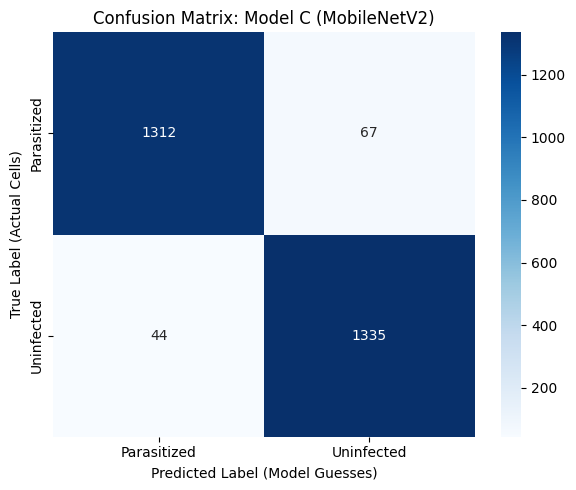

In [17]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract the true labels
print("Extracting true labels...")
true_labels = np.concatenate([y for x, y in test_ds_mobile], axis=0)

# 2. Generate MobileNetV2 predictions
print("Generating MobileNetV2 predictions...")
raw_predictions_mobile = model_mobile.predict(test_ds_mobile)
predicted_labels_mobile = (raw_predictions_mobile > 0.5).astype(int).flatten()

# 3. Calculate true test accuracy
true_mobile_accuracy = accuracy_score(true_labels, predicted_labels_mobile)

print("\n=========================================")
print(f"👉 TRUE MOBILENETV2 TEST ACCURACY: {true_mobile_accuracy:.3f}")
print("=========================================\n")

# 4. Print Scores Report
class_names = ['Parasitized', 'Uninfected']
print("=== CLASSIFICATION REPORT ===")
print(classification_report(true_labels, predicted_labels_mobile, target_names=class_names, digits=3))

# 5. Plot the Confusion Matrix
cm_mobile = confusion_matrix(true_labels, predicted_labels_mobile)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_mobile, 
    annot=True,          
    fmt="d",             
    cmap="Blues",        
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title("Confusion Matrix: Model C (MobileNetV2)")
plt.ylabel("True Label (Actual Cells)")
plt.xlabel("Predicted Label (Model Guesses)")
plt.tight_layout()
plt.show()


In [18]:
# Save this winning production model to your models folder
model_mobile.save(r"C:\Users\Bright\Desktop\ds_today\project\models\malaria_final_production.keras")
print("✅ Final winning model saved successfully!")


✅ Final winning model saved successfully!
